In [37]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader 
import torchvision.utils as vutils
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob,os,math
from tqdm import tqdm

In [2]:
!git clone https://github.com/ChinmoyGitPy/Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon.git

Cloning into 'Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon'...
remote: Enumerating objects: 1360, done.
remote: Counting objects: 100% (1360/1360), done.
remote: Compressing objects: 100% (1327/1327), done.
remote: Total 1360 (delta 36), reused 1354 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (1360/1360), 15.31 MiB | 18.85 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
path = glob.glob('Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon/moon/*')

sizes = []
for p in tqdm(path[:200]):
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception as e:
        print(f"Bad file: {p} -> {e}")
print("Unique sizes:",set(sizes))

100%|██████████| 200/200 [00:00<00:00, 1573.88it/s]

Unique sizes: {(320, 297), (231, 240), (239, 232), (239, 229), (229, 240), (240, 240), (222, 240), (233, 240), (240, 221), (240, 227), (240, 224), (238, 239), (240, 230), (240, 233), (240, 239), (240, 236), (320, 296), (100, 67), (224, 240), (237, 240), (226, 240), (239, 240), (240, 231), (240, 220), (235, 239), (240, 229), (240, 223), (240, 226), (240, 235), (230, 240), (240, 238), (232, 240), (239, 239), (234, 240), (240, 219), (240, 225), (236, 240), (225, 240), (240, 228), (240, 234), (227, 240), (238, 240), (240, 237), (320, 291), (218, 240), (232, 239), (320, 294)}


In [4]:
def clean_corrupted(file_list):
    bad = []
    for p in tqdm(file_list):
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception:
            bad.append(p)

    for b in bad:
        os.remove(b)
        file_list.remove(b)

    print(f"removed {len(bad)}, remaining: {len(file_list)}")
    return file_list

path = clean_corrupted(path)

100%|██████████| 1344/1344 [00:00<00:00, 8550.26it/s]

removed 0, remaining: 1344


Surprisingly enough not a single bad file!! But I manually flagged some images for removal since the dataset wasnt that big.

Found20/20 flagged files


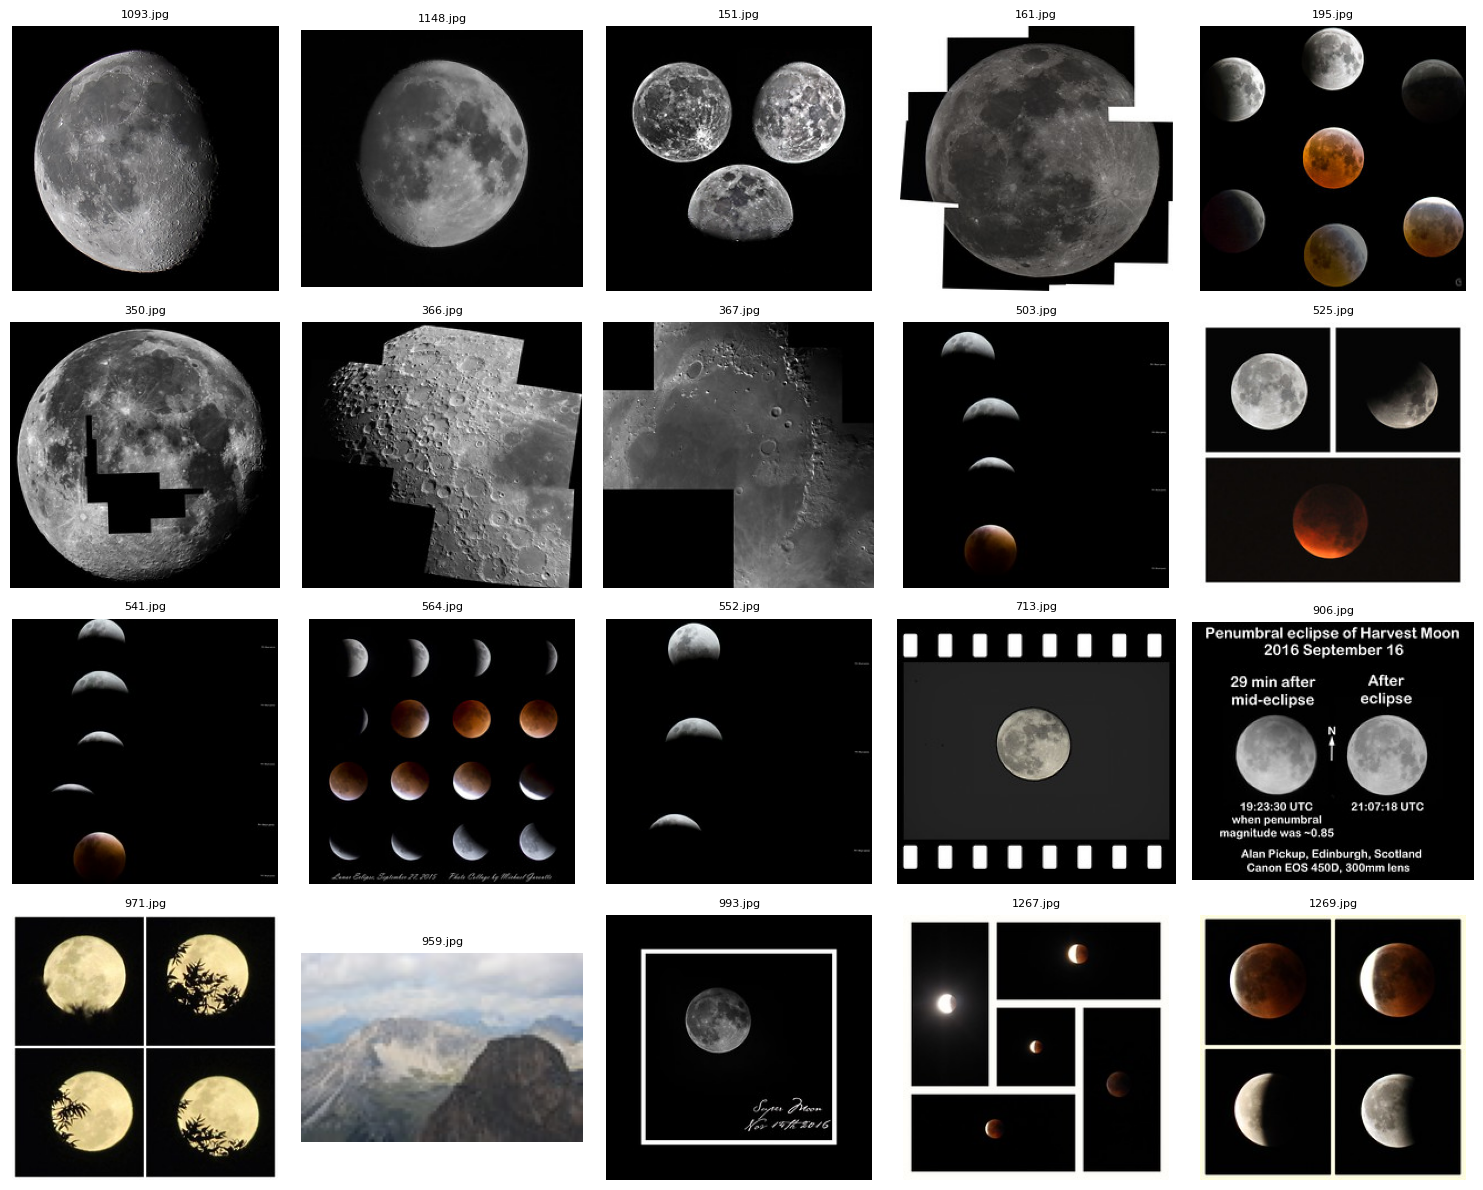

In [5]:
flagged_ids = [109,114,151,161,195,350,366,367,503,525,541,564,552,
               713,906,971,959,993,1267,1269]

def find_file(file_list,id_):
    for p in file_list:
        fname = os.path.basename(p)
        if fname == f"{id_}.jpg" or fname.startswith(f"{id_}") or f"_{id_}." in fname:
            return p
    return None

flagged_paths = []
for id_ in flagged_ids:
    fp = find_file(path,id_)
    if fp:
        flagged_paths.append(fp)
    else:
        print(f"Could not find file for {id_}")

print(f"Found{len(flagged_paths)}/{len(flagged_ids)} flagged files")

n = len(flagged_paths)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

for i, fp in enumerate(flagged_paths):
    img = Image.open(fp)
    axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
    axes[i].set_title(os.path.basename(fp), fontsize=8)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Voila! I guess it's obvious why we must've removed these..

In [9]:
def remove_flagged(file_list,flagged_ids):
    removed = []
    remaining = []
    for p in file_list:
        fname = os.path.basename(p)
        id_ = os.path.splitext(fname)[0]
        try:
            id_num = int(id_.split('_')[-1]if '_' in id_ else int(id_))
        except ValueError:
            id_num = None

        if id_num in flagged_ids:
            removed.append(p)
        else:
            remaining.append(p)

    print(f"Flagged for removal: {len(removed)}")
    for p in removed:
        os.remove(p)
    return remaining

path = remove_flagged(path,flagged_ids)

Flagged for removal: 20


Treating as grayscale (1 channel) and image size = 64

In [10]:
out_dir = "data/moon_processed"
os.makedirs(out_dir,exist_ok=True)
IMG_SIZE = 64

def process_grayscale(file_list,out_dir,image_size=64):
    for i,p in enumerate(tqdm(file_list)):
        try:
            img = Image.open(p).convert("L")
        except Exception:
            continue
        w,h = img.size
        scale = image_size/min(w,h)
        img = img.resize((int(w*scale),int(h*scale)), Image.LANCZOS)
        w2,h2 = img.size
        left,top = (w2-image_size)//2,(h2-image_size)//2
        img = img.crop((left,top,left+image_size,top+image_size))
        img.save(os.path.join(out_dir,f"moon_{i:05d}.png"))

process_grayscale(path,out_dir,IMG_SIZE)

100%|██████████| 1324/1324 [00:02<00:00, 527.18it/s]


In [11]:
class MoonDataset(Dataset):
    def __init__(self,root_dir,image_size=64,channels=1):
        self.files = glob.glob(os.path.join(root_dir,'*.png'))
        self.channels = channels
        mean = [0.5]*channels
        std = [0.5]*channels
        self.transform = T.Compose([
            T.Resize((image_size,image_size)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean,std)
        ])
    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        img = Image.open(self.files[idx]).convert("L")
        return self.transform(img)

dataset = MoonDataset(out_dir,image_size=IMG_SIZE,channels=1)
dataloader = DataLoader(dataset,batch_size=64,shuffle=True,num_workers=4,pin_memory=True,drop_last=True)
batch = next(iter(dataloader))
print(batch.shape,batch.min().item(),batch.max().item())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

torch.Size([64, 1, 64, 64]) -1.0 1.0


Now I'm gonna check the images again after grayscaling, cropping, normalising for a quick sanity check that what the model will see..

Batch Shape: torch.Size([64, 1, 64, 64])
Value range: <built-in method item of Tensor object at 0x7a6dd0e1b0c0> to 1.0


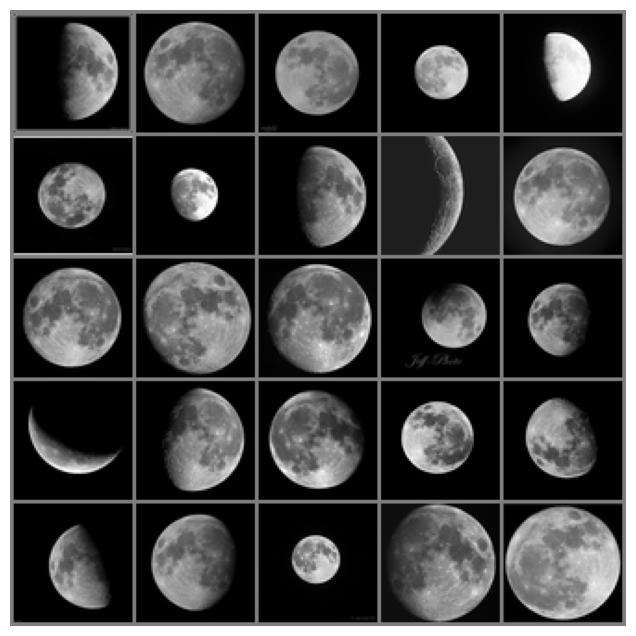

In [12]:
batch = next(iter(dataloader))
print("Batch Shape:", batch.shape)
print("Value range:",batch.min().item,"to",batch.max().item())

grid = vutils.make_grid(batch[:25],nrow=5,normalize=False)
grid_display = (grid+1)/2

plt.figure(figsize=(8,8))
plt.imshow(grid_display.permute(1,2,0).squeeze(),cmap='gray')
plt.axis('off')
plt.show()

Nice, as expected. Next we're moving to noise scheduiling..

In [33]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start,end,timesteps)

def cosine_beta_schedule(timesteps,s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0,timesteps,steps)
    alphas_cumprod = torch.cos(((x/timesteps)+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod/alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,0.0001,0.9999)

def get_index_from_list(vals,t,x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1,t.cpu())
    return out.reshape(batch_size,*((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0,t,device="cpu"):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod,t,x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod,t,x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
    +sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device),noise.to(device)

T_STEPS = 150
SCHEDULE = "cosine"
if SCHEDULE == "cosine":
    betas = cosine_beta_schedule(timesteps=T_STEPS)
else:
    betas = linear_beta_schedule(timesteps=T_STEPS)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas,axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1],(1,0),value=1.0)
sqrt_recip_alias = torch.sqrt(1.0/alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.-alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev)/(1.-alphas_cumprod)


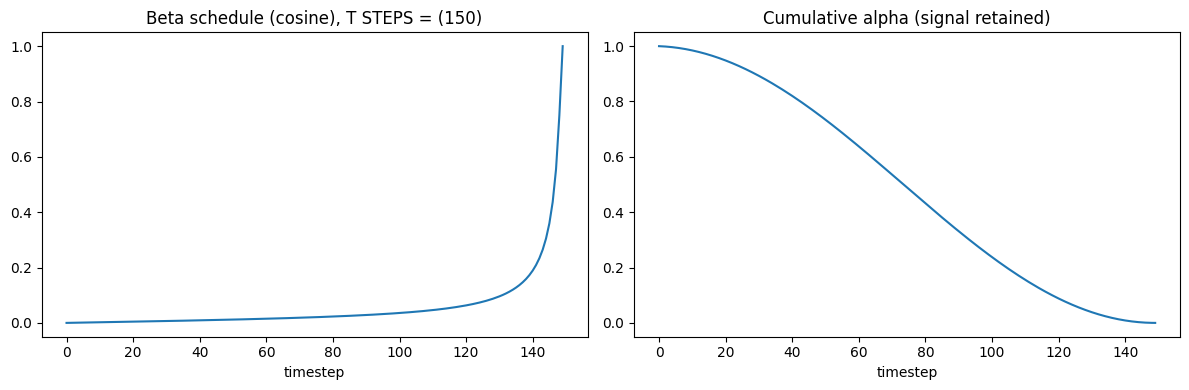

In [34]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(betas.numpy())
axes[0].set_title(f"Beta schedule ({SCHEDULE}), T STEPS = ({T_STEPS})")
axes[0].set_xlabel("timestep")

axes[1].plot(alphas_cumprod.numpy())
axes[1].set_title("Cumulative alpha (signal retained)")
axes[1].set_xlabel("timestep")

plt.tight_layout()
plt.show()

In [35]:
def show_tensor_image(image):
    reverse_transforms = T.Compose([
        T.Lambda(lambda t: (t+1)/2),
        T.Lambda(lambda t: t.clamp(0,1)),
        T.Lambda(lambda t: t.permute(1,2,0)),
        T.Lambda(lambda t: t* 255.),
        T.Lambda(lambda t: t.numpy().astype(np.uint8)),
        T.Lambda(lambda t: t.squeeze(-1) if t.shape[-1]==1 else t),
        T.ToPILImage(),
    ])
    if len(image.shape) == 4:
        image = image[0,:,:,:]
    plt.imshow(reverse_transforms(image.cpu()),cmap="gray")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


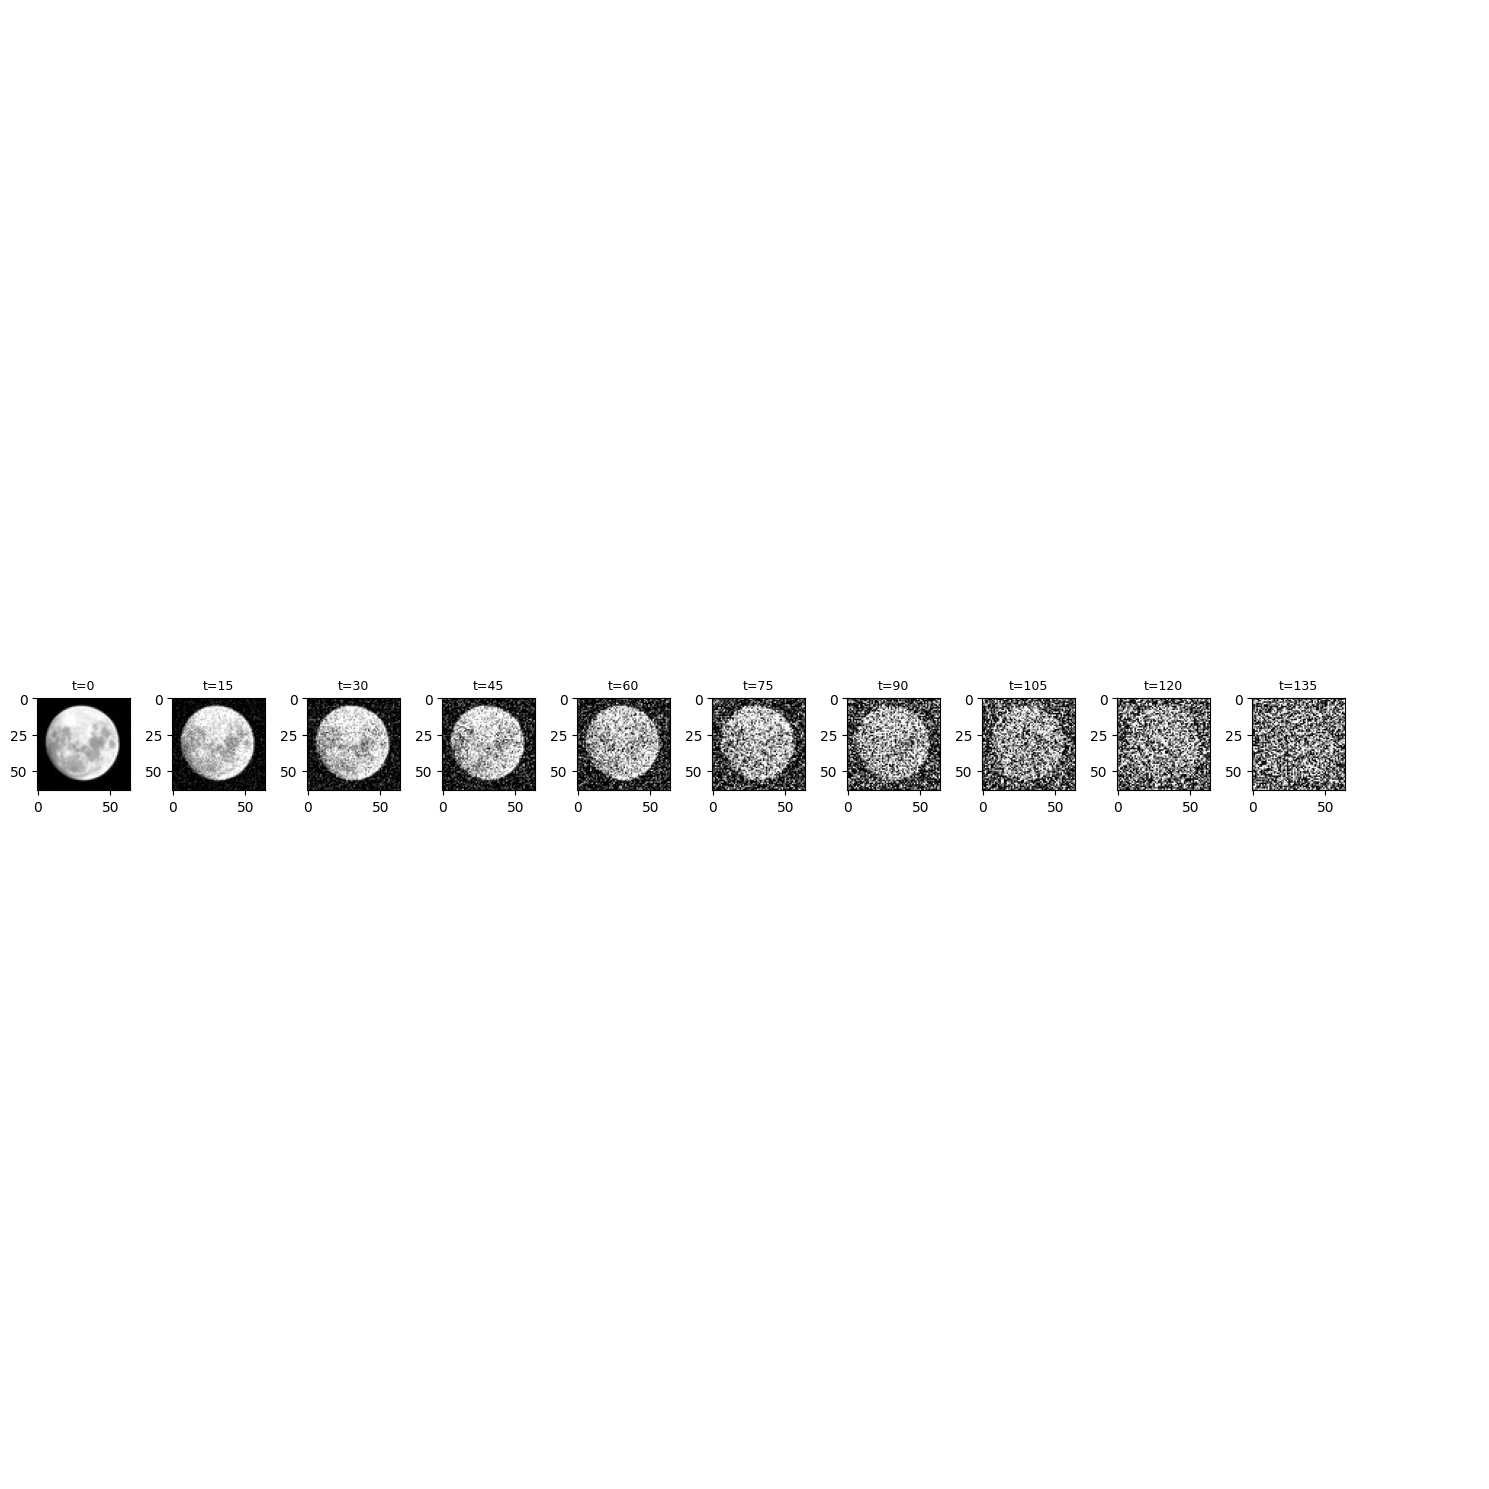

In [36]:
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T_STEPS/num_images)

for idx in range(0,T_STEPS,stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1,num_images + 1, int(idx/stepsize)+1)
    img,noise = forward_diffusion_sample(image,t)
    show_tensor_image(img)
    plt.title(f"t={idx}",fontsize=9)

plt.tight_layout()
plt.show()